In [1]:
from IPython.display import display
import numpy as np
import pandas as pd

In [2]:
pd.set_option('display.max_rows', None)

In [3]:
matches = pd.read_excel('new-results-april-26.xlsx')
penalty = pd.read_excel('penalty-shootouts-26.xlsx')

In [4]:
unique_teams = list(set(matches['home_team'].unique()) | set(matches['away_team'].unique()))
len(unique_teams)

249

In [5]:
sorted_unique_teams = sorted(unique_teams)
print(sorted_unique_teams)

['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bonaire', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chameria', 'Chile', 'China PR', 'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'CuraÃ§ao', 'Cyprus', 'Czech Republic', 'DR Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'Equatorial Guinea', 'Estonia', 'Eswatini', 'Ethiopia', 'Falkland Islands', 'Faroe Islands', 'Fiji', 'Finland', 'France', 'French Guiana', 'FrÃ¸ya', 'Gabon', 'Gambia', 'Georgia', 'Germany', '

In [6]:
replace_from = ['Czech Republic', 'DR Congo', 'Iran', 'Ivory Coast', 'South Korea', 'Turkey', 'Cape Verde', 'United States', 'CuraÃ§ao']
replace_to = ['Czechia', 'Congo DR', 'IR Iran', "Côte d'Ivoire", 'Korea Republic','Turkiye', 'Cabo Verde', 'USA', 'Curacao']

In [7]:
matches['home_team'].replace(replace_from, replace_to, inplace=True)
matches['away_team'].replace(replace_from, replace_to, inplace=True)
matches['country'].replace(replace_from, replace_to, inplace=True)

/tmp/ipykernel_19357/3014100219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['home_team'].replace(replace_from, replace_to, inplace=True)
/tmp/ipykernel_19357/3014100219.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [8]:
unique_teams = list(set(matches['home_team'].unique()) | set(matches['away_team'].unique()))
len(unique_teams)

249

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import seaborn as sns
from scipy.stats import poisson
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools
from IPython.display import display, HTML

In [10]:
matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2022-11-20,Qatar,Ecuador,0,2,FIFA World Cup,Al Khor,Qatar,False
1,2022-11-21,Senegal,Netherlands,0,2,FIFA World Cup,Doha,Qatar,True
2,2022-11-21,England,IR Iran,6,2,FIFA World Cup,Al Rayyan,Qatar,True
3,2022-11-21,USA,Wales,1,1,FIFA World Cup,Al Rayyan,Qatar,True
4,2022-11-22,Argentina,Saudi Arabia,1,2,FIFA World Cup,Lusail,Qatar,True


In [11]:
matches = matches.astype({'date':'datetime64[ns]'})

In [12]:

home = matches[['home_team', 'home_score']].rename(columns={'home_team':'team', 'home_score':'score'})
away = matches[['away_team', 'away_score']].rename(columns={'away_team':'team', 'away_score':'score'})
# merge it into one
team_score = home._append(away).reset_index(drop=True)
# make an aggregation of the the score column group by the team
country_info = team_score.groupby('team')['score'].agg(['sum','count','mean']).reset_index()
country_info = country_info.rename(columns={'sum':'nb_goals', 'count':'nb_matches', 'mean':'goal_avg'})

del home, away

In [13]:
means = matches[['home_score','away_score']].mean()
means

,0
home_score,1.619802
away_score,1.155304


/tmp/ipykernel_19357/1795165113.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  poisson_pred = np.column_stack([[poisson.pmf(k, means[j]) for k in range(10)] for j in range(2)])


ValueError: The number of FixedLocator locations (10), usually from a call to set_ticks, does not match the number of labels (11).

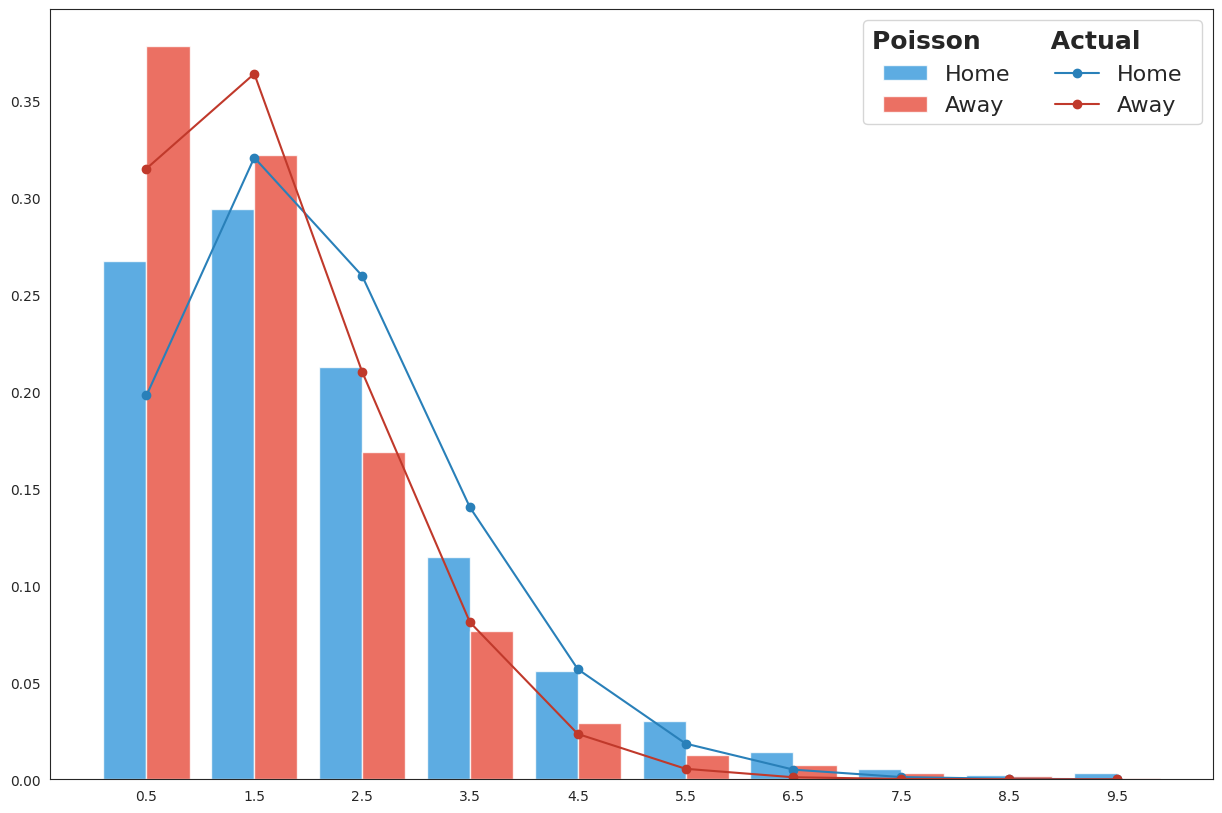

In [14]:
plt.figure(figsize=(15,10))
sns.set_style("white")
# construct Poisson  for each mean goals value
poisson_pred = np.column_stack([[poisson.pmf(k, means[j]) for k in range(10)] for j in range(2)])
# plot histogram of actual goals
plt.hist(matches[['home_score', 'away_score']].values, range(11), alpha=0.8,
         label=['Home', 'Away'],density=True, color=["#3498db", "#e74c3c"])

# add lines for the Poisson distributions
pois1, = plt.plot([i-0.5 for i in range(1,11)], poisson_pred[:,0],
                  linestyle='-', marker='o',label="Home", color = '#2980b9')
pois2, = plt.plot([i-0.5 for i in range(1,11)], poisson_pred[:,1],
                  linestyle='-', marker='o',label="Away", color = '#c0392b')

leg=plt.legend(loc='upper right', fontsize=16, ncol=2)
leg.set_title("Poisson        Actual      ", prop = {'size':'18', 'weight':'bold'})

plt.xticks([i-0.5 for i in range(1,11)],[i for i in range(11)])
plt.xlabel("Goals per Match",size=18)
plt.ylabel("Proportion of Matches",size=18)
plt.title("Number of Goals per Match",size=20,fontweight='bold')
plt.show()

ValueError: The number of FixedLocator locations (10), usually from a call to set_ticks, does not match the number of labels (11).

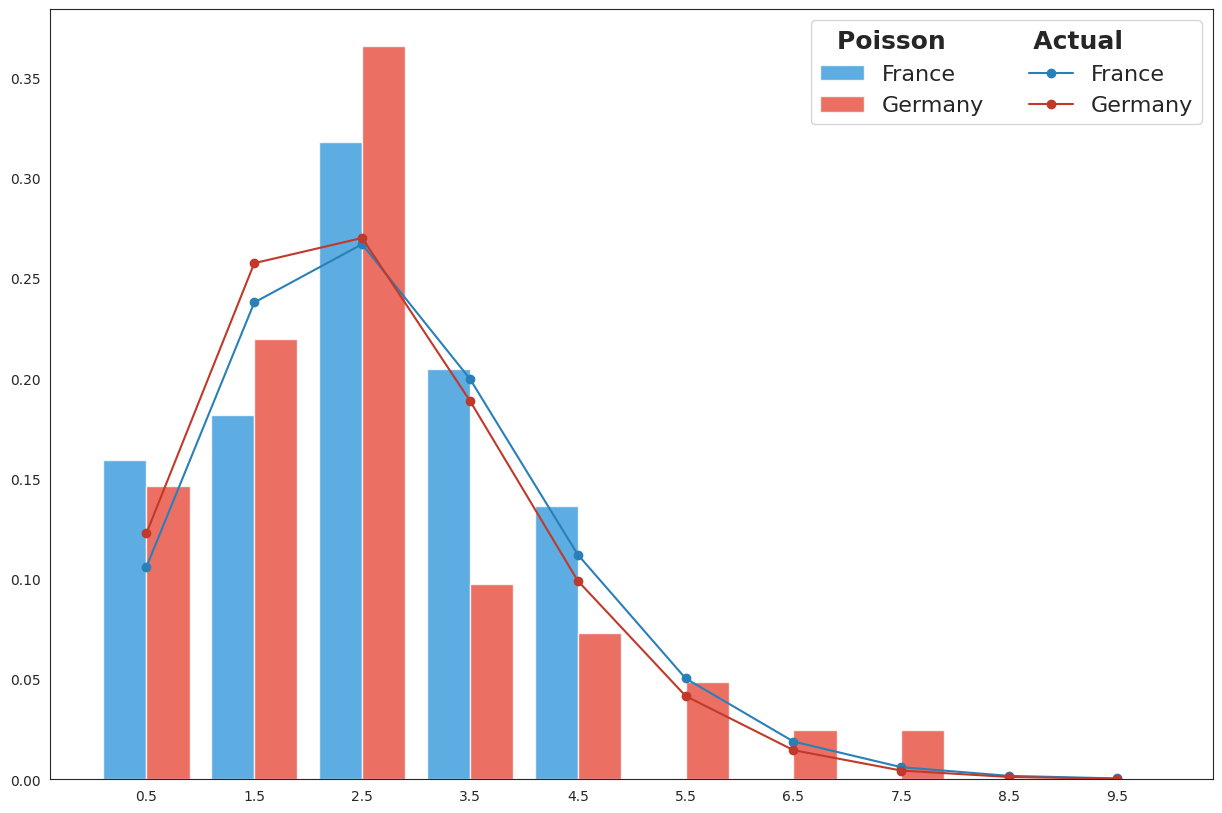

In [15]:
plt.figure(figsize=(15,10))
sns.set_style("white")
team1, team2 = "France", "Germany"
matches_t1 = team_score[team_score['team'] == team1]
matches_t2 = team_score[team_score['team'] == team2]

mean_t1 = matches_t1['score'].mean()
mean_t2 = matches_t2['score'].mean()

# construct Poisson  for each mean goals value
poisson_pred_t1 = [poisson.pmf(k, mean_t1) for k in range(10)]
poisson_pred_t2 = [poisson.pmf(k, mean_t2) for k in range(10)]

# plot histogram of actual goals
plt.hist([matches_t1['score'].values, matches_t2['score'].values], range(11), alpha=0.8,
         label=[team1, team2],density=True, color=["#3498db", "#e74c3c"])

# add lines for the Poisson distributions
pois1, = plt.plot([i-0.5 for i in range(1,11)], poisson_pred_t1,
                  linestyle='-', marker='o',label=team1, color = '#2980b9')
pois2, = plt.plot([i-0.5 for i in range(1,11)], poisson_pred_t2,
                  linestyle='-', marker='o',label=team2, color = '#c0392b')

leg=plt.legend(loc='upper right', fontsize=16, ncol=2)
leg.set_title("Poisson          Actual      ", prop = {'size':'18', 'weight':'bold'})

plt.xticks([i-0.5 for i in range(1,11)],[i for i in range(11)])
plt.xlabel("Goals per Match",size=18)
plt.ylabel("Proportion of Matches",size=18)
plt.title("Number of Goals per Match",size=20,fontweight='bold')
plt.show

In [16]:
matches['tournament'].unique()

array(['FIFA World Cup', 'Friendly', 'AFF Championship', 'Gulf Cup',
       'Tri Nation Tournament', 'African Cup of Nations qualification',
       'UEFA Euro qualification', 'CONCACAF Nations League',
       'CAFA Nations Cup', 'Mauritius Four Nations Cup',
       'UEFA Nations League', 'Gold Cup qualification',
       'CONIFA World Football Cup qualification', 'SAFF Cup', 'Gold Cup',
       'COSAFA Cup', 'Island Games', 'CONIFA Asia Cup',
       'Indian Ocean Island Games', 'FIFA World Cup qualification',
       "King's Cup", "MSG Prime Minister's Cup", 'Soccer Ashes',
       'Pacific Games', 'AFC Asian Cup', 'African Cup of Nations',
       'Oceania Nations Cup qualification', 'FIFA Series',
       'Copa AmÃ©rica qualification', 'Marianas Cup', 'Baltic Cup',
       'UEFA Euro', 'Oceania Nations Cup', 'Copa AmÃ©rica',
       'Tri-Nations Series', 'Intercontinental Cup', 'Merdeka Tournament',
       'AFC Asian Cup qualification', 'ASEAN Championship qualification',
       'ASEAN Champ

In [17]:
matches['id'] = range(1, len(matches) + 1)

In [18]:
def weight_from_tournament(tournament):
    priority = {
        'FIFA World Cup': 1,
        'UEFA Euro': 2,
        'Copa AmÃ©rica': 2,
        'African Cup of Nations': 2,
        'AFC Asian Cup': 2,
        'Gold Cup': 2,
        'Oceania Nations Cup': 2,
        'CAFA Nations Cup': 3,
        'EAFF Championship': 3,
        'WAFF Championship': 3,
        'COSAFA Cup': 3,
        'SAFF Cup': 3,
        'AFF Championship': 3,
        'West African Cup': 3,
        'CECAFA Cup': 3,
        'Gulf Cup': 3,
        'Arab Cup': 3,
        'CAFA Nations Cup': 3,
        'FIFA World Cup qualification': 4,
        'CONCACAF Nations League': 4,
        'UEFA Nations League': 4,
        'Africa Cup of Nations qualification': 5,
        'Gold Cup qualification': 5,
        'Oceania Nations Cup qualification': 5,
        'UEFA Euro qualification': 5,
        'CONCACAF Nations League qualification': 6,
        'AFF Championship qualification': 6,
        'COSAFA Cup qualification': 6,
        'Arab Cup qualification': 6,
        'FIFA Series': 7
    }

    if tournament in priority:
        return priority[tournament]
    elif 'Friendly' in tournament:
        return 9
    else:
        return 8

In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Filter matches based on the given criteria
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Filter matches based on the given criteria
matches_filtered = matches[(matches['id'] >= 0) & (matches['id'] <= 5518)].copy()
# Apply the weighting function to create the 'weight' column
matches_filtered['weight'] = matches_filtered['tournament'].apply(weight_from_tournament)

matches_filtered['weight'] = pd.to_numeric(matches_filtered['weight'], errors='coerce')

# Replace 0 with a very small positive value (statsmodels rejects 0 weight)
matches_filtered.loc[matches_filtered['weight'] == 0, 'weight'] = np.nan

# Now invert
matches_filtered['weight'] = 1 / matches_filtered['weight']

# Clean again
matches_filtered['weight'] = pd.to_numeric(matches_filtered['weight'], errors='coerce')

# Drop invalid values before creating model data
matches_filtered = matches_filtered.dropna(subset=['weight'])
matches_filtered = matches_filtered[matches_filtered['weight'] > 0]


# Create model data
matches_model_data = pd.concat([
    matches_filtered[['home_team', 'away_team', 'home_score', 'neutral', 'weight']].rename(
        columns={'home_team': 'team', 'away_team': 'opponent', 'home_score': 'goals'}),
    matches_filtered[['away_team', 'home_team', 'away_score', 'neutral', 'weight']].rename(
        columns={'away_team': 'team', 'home_team': 'opponent', 'away_score': 'goals'})
])


# Remove rows with invalid weights
invalid_values = matches_model_data['weight'].isnull() | np.isinf(matches_model_data['weight'])
matches_model_data = matches_model_data[~invalid_values]

poisson_model = smf.glm(
    formula="goals ~ team + opponent",
    data=matches_model_data,
    family=sm.families.Poisson()
).fit_regularized(alpha=1e-4)

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


In [20]:
print(matches_model_data['weight'].describe())
print(matches_model_data['weight'].unique()[:20])
print(matches_model_data['weight'].isnull().sum(), "nulls")
print((matches_model_data['weight'] == 0).sum(), "zeros")
print((matches_model_data['weight'] < 0).sum(), "negative")
print(np.isinf(matches_model_data['weight']).sum(), "inf")


count    7070.000000
mean        0.232179
std         0.151230
min         0.111111
25%         0.125000
50%         0.250000
75%         0.250000
max         1.000000
Name: weight, dtype: float64
[1.         0.11111111 0.33333333 0.125      0.2        0.25
 0.5        0.14285714 0.16666667]
0 nulls
0 zeros
0 negative
0 inf


In [21]:
def get_proba_match(foot_model, team1, team2, neutral=False, max_goals=10):
    # Get the average goal for each team
    t1_goals_avg = foot_model.predict(pd.DataFrame(data={'team': team1, 'opponent': team2}, index=[1])).values[0]
    t2_goals_avg = foot_model.predict(pd.DataFrame(data={'team': team2, 'opponent': team1}, index=[1])).values[0]

    # Get probability of all possible score for each team
    team_pred = [[poisson.pmf(i, team_avg) for i in range(0, max_goals+1)] for team_avg in [t1_goals_avg, t2_goals_avg]]

    # Do the product of the 2 vectors to get the matrix of the match
    match = np.outer(np.array(team_pred[0]), np.array(team_pred[1]))

    # Get the proba for each possible outcome
    t1_wins = np.sum(np.tril(match, -1))
    draw = np.sum(np.diag(match))
    t2_wins = np.sum(np.triu(match, 1))
    result_proba = [t1_wins, draw, t2_wins]

    # Adjust the proba to sum to one
    result_proba =  np.array(result_proba)/ np.array(result_proba).sum(axis=0,keepdims=1)
    team_pred[0] = np.array(team_pred[0])/np.array(team_pred[0]).sum(axis=0,keepdims=1)
    team_pred[1] = np.array(team_pred[1])/np.array(team_pred[1]).sum(axis=0,keepdims=1)
    return result_proba, [np.array(team_pred[0]), np.array(team_pred[1])]

In [22]:
def get_match_result(foot_model, team1, team2, elimination=False, neutral=False, max_draw=50, max_goals=10):
    # Get the proba
    proba, score_proba = get_proba_match(foot_model, team1, team2,neutral, max_goals)

    # Get the result, if it's an elimination game we have to be sure the result is not draw
    results = pd.Series([np.random.choice([team1, 'draw', team2], p=proba) for i in range(0,max_draw)]).value_counts()
    result = results.index[0] if not elimination or (elimination and results.index[0] != 'draw') else results.index[1]

    # If the result is not a draw game then we calculate the score of the winner from 1 to the max_goals
    # and the score of the looser from 0 to the score of the winner
    if (result != 'draw'):
        i_win, i_loose = (0,1) if result == team1 else (1,0)
        score_proba[i_win] = score_proba[i_win][1:]/score_proba[i_win][1:].sum(axis=0,keepdims=1)
        winner_score = pd.Series([np.random.choice(range(1, max_goals+1), p=score_proba[i_win]) for i in range(0,max_draw)]).value_counts().index[0]
        score_proba[i_loose] = score_proba[i_loose][:winner_score]/score_proba[i_loose][:winner_score].sum(axis=0,keepdims=1)
        looser_score = pd.Series([np.random.choice(range(0, winner_score), p=score_proba[i_loose]) for i in range(0,max_draw)]).value_counts().index[0]
        score = [winner_score, looser_score]
    # If it's a draw then we calculate a score and repeat it twice
    else:
        score = np.repeat(pd.Series([np.random.choice(range(0, max_goals+1), p=score_proba[0]) for i in range(0,max_draw)]).value_counts().index[0],2)
    looser = team2 if result == team1 else team1 if result != 'draw' else 'draw'
    return result, looser, score

In [23]:
print(get_match_result(poisson_model, 'Argentina', 'Germany', neutral=True))
print(get_match_result(poisson_model, 'Argentina', 'Peru', neutral=False))
print(get_match_result(poisson_model, 'India', 'Argentina', neutral=False))

(np.str_('Argentina'), 'Germany', [np.int64(1), np.int64(0)])
(np.str_('Argentina'), 'Peru', [np.int64(1), np.int64(0)])
(np.str_('Argentina'), 'India', [np.int64(2), np.int64(0)])


PlayOffs<br>
Path A: Wales, Bosnia, Italy, Northern Ireland<br>
Path B: Ukraine, Sweden, Poland, Albania<br>
Path C: Slovakia, Kosovo, Turkey, Romania<br>
Path D: Czechia, Republic of Ireland, Denmark<br>
Path E: Iraq, Bolivia, Suriname<br>
Path F: Congo DR, Jamaica, New Caledonia

In [ ]:
print(get_match_result(poisson_model, 'Wales', 'Bosnia and Herzegovina',elimination=True, neutral=False)) # Path A Semi
print(get_match_result(poisson_model, 'Italy', 'Northern Ireland',elimination=True, neutral=False)) # Path A Semi
print(get_match_result(poisson_model, 'Ukraine', 'Sweden',elimination=True, neutral=True)) # Path B Semi
print(get_match_result(poisson_model, 'Poland', 'Albania',elimination=True, neutral=False)) # Path B Semi
print(get_match_result(poisson_model, 'Slovakia', 'Kosovo',elimination=True, neutral=False)) # Path C Semi
print(get_match_result(poisson_model, 'Turkiye', 'Romania',elimination=True, neutral=False)) # Path C Semi
print(get_match_result(poisson_model, 'Czechia', 'Republic of Ireland',elimination=True, neutral=False)) # Path D Semi
print(get_match_result(poisson_model, 'Denmark', 'North Macedonia',elimination=True, neutral=False)) # Path D Semi
print(get_match_result(poisson_model, 'Bolivia', 'Suriname',elimination=True, neutral=True)) # Path E Semi
print(get_match_result(poisson_model, 'Jamaica', 'New Caledonia',elimination=True, neutral=True)) # Path F Semi


(np.str_('Wales'), 'Bosnia and Herzegovina', [np.int64(1), np.int64(0)])
(np.str_('Italy'), 'Northern Ireland', [np.int64(1), np.int64(0)])
(np.str_('Sweden'), 'Ukraine', [np.int64(1), np.int64(0)])
(np.str_('Poland'), 'Albania', [np.int64(1), np.int64(0)])
(np.str_('Slovakia'), 'Kosovo', [np.int64(1), np.int64(0)])
(np.str_('Turkiye'), 'Romania', [np.int64(2), np.int64(0)])
(np.str_('Czechia'), 'Republic of Ireland', [np.int64(1), np.int64(0)])
(np.str_('Denmark'), 'North Macedonia', [np.int64(1), np.int64(0)])
(np.str_('Bolivia'), 'Suriname', [np.int64(2), np.int64(0)])
(np.str_('Jamaica'), 'New Caledonia', [np.int64(1), np.int64(0)])


In [ ]:
print(get_match_result(poisson_model, 'Wales', 'Italy',elimination=True, neutral=False)) # Path A Final
print(get_match_result(poisson_model, 'Sweden', 'Poland',elimination=True, neutral=False)) # Path B Final
print(get_match_result(poisson_model, 'Slovakia', 'Turkiye',elimination=True, neutral=False)) # Path C Final
print(get_match_result(poisson_model, 'Czechia', 'Denmark',elimination=True, neutral=False)) # Path D Final
print(get_match_result(poisson_model, 'Iraq', 'Bolivia',elimination=True, neutral=True)) # Path E Finak
print(get_match_result(poisson_model, 'Congo DR', 'Jamaica',elimination=True, neutral=True)) # Path F Final

(np.str_('Italy'), 'Wales', [np.int64(1), np.int64(0)])
(np.str_('Sweden'), 'Poland', [np.int64(1), np.int64(0)])
(np.str_('Turkiye'), 'Slovakia', [np.int64(1), np.int64(0)])
(np.str_('Denmark'), 'Czechia', [np.int64(1), np.int64(0)])
(np.str_('Bolivia'), 'Iraq', [np.int64(1), np.int64(0)])
(np.str_('Congo DR'), 'Jamaica', [np.int64(1), np.int64(0)])


In [24]:
groupA = ['Mexico', 'South Africa','Korea Republic','Czechia']
groupB = ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland']
groupC = ['Brazil', 'Morocco', 'Haiti', 'Scotland']
groupD = ['USA', 'Paraguay', 'Australia', 'Turkiye']
groupE = ['Germany', 'Curacao', "Côte d'Ivoire", 'Ecuador']
groupF = ['Netherlands', 'Japan', 'Tunisia', 'Sweden']
groupG = ['Belgium', 'Egypt','IR Iran','New Zealand']
groupH = ['Spain', 'Cabo Verde', 'Saudi Arabia', 'Uruguay']
groupI = ['France', 'Senegal', 'Iraq', 'Norway']
groupJ = ['Argentina', 'Algeria', 'Austria', 'Jordan']
groupK = ['Portugal', 'Congo DR', 'Uzbekistan', 'Colombia']
groupL = ['England', 'Croatia', 'Ghana', 'Panama']
groups = [groupA, groupB, groupC, groupD, groupE, groupF, groupG, groupH, groupI, groupJ, groupK, groupL]

In [25]:
import pandas as pd
import itertools

def get_group_result(foot_model, group,neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))):
    ranking = pd.DataFrame({'points': [0, 0, 0, 0], 'diff': [0, 0, 0, 0], 'goals': [0, 0, 0, 0]}, index=group)
    match_results = []  # List to store results of individual matches

    for team1, team2 in itertools.combinations(group, 2):
        result, looser, score = get_match_result(foot_model, team1, team2)
        match_result = {
            'team1': team1,
            'team2': team2,
            'score': f"{score[0]} - {score[1]}"
        }

        if result == 'draw':
            ranking.loc[[team1, team2], 'points'] += 1
            ranking.loc[[team1, team2], 'goals'] += score[0]
            match_result['result'] = 'Draw'
        else:
            ranking.loc[result, 'points'] += 3
            ranking.loc[result, 'goals'] += score[0]
            ranking.loc[looser, 'goals'] += score[1]
            ranking.loc[result, 'diff'] += score[0] - score[1]
            ranking.loc[looser, 'diff'] -= score[0] - score[1]
            match_result['result'] = f"{result} wins"

        match_results.append(match_result)  # Append match results to the list

    # Convert list of match results to a DataFrame for easier viewing
    matches_df = pd.DataFrame(match_results)
    sorted_ranking = ranking.sort_values(by=['points', 'diff', 'goals'], ascending=False)

    return sorted_ranking, matches_df  # Return both standings and match resu
# Example usage
groups_ranking = []
match_details = []

for group in groups:
    ranking, matches = get_group_result(poisson_model, group)
    groups_ranking.append(ranking)
    match_details.append(matches)

# Display results
for group_rank, matches in zip(groups_ranking, match_details):
    display(group_rank)
    display(matches)

,points,diff,goals
Mexico,9,3,3
Korea Republic,6,1,2
South Africa,1,-2,1
Czechia,1,-2,1


,team1,team2,score,result
0,Mexico,South Africa,1 - 0,Mexico wins
1,Mexico,Korea Republic,1 - 0,Mexico wins
2,Mexico,Czechia,1 - 0,Mexico wins
3,South Africa,Korea Republic,1 - 0,Korea Republic wins
4,South Africa,Czechia,1 - 1,Draw
5,Korea Republic,Czechia,1 - 0,Korea Republic wins


,points,diff,goals
Switzerland,9,3,3
Canada,6,2,4
Qatar,3,0,3
Bosnia and Herzegovina,0,-5,0


,team1,team2,score,result
0,Canada,Bosnia and Herzegovina,2 - 0,Canada wins
1,Canada,Qatar,2 - 1,Canada wins
2,Canada,Switzerland,1 - 0,Switzerland wins
3,Bosnia and Herzegovina,Qatar,2 - 0,Qatar wins
4,Bosnia and Herzegovina,Switzerland,1 - 0,Switzerland wins
5,Qatar,Switzerland,1 - 0,Switzerland wins


,points,diff,goals
Morocco,9,4,4
Brazil,6,3,4
Scotland,3,-3,1
Haiti,0,-4,0


...

,team1,team2,score,result
0,Argentina,Algeria,2 - 0,Argentina wins
1,Argentina,Austria,1 - 0,Argentina wins
2,Argentina,Jordan,3 - 0,Argentina wins
3,Algeria,Austria,1 - 0,Austria wins
4,Algeria,Jordan,2 - 0,Algeria wins
5,Austria,Jordan,1 - 0,Austria wins


,points,diff,goals
Colombia,9,4,5
Portugal,6,1,3
Congo DR,1,-2,0
Uzbekistan,1,-3,0


,team1,team2,score,result
0,Portugal,Congo DR,1 - 0,Portugal wins
1,Portugal,Uzbekistan,1 - 0,Portugal wins
2,Portugal,Colombia,2 - 1,Colombia wins
3,Congo DR,Uzbekistan,0 - 0,Draw
4,Congo DR,Colombia,1 - 0,Colombia wins
5,Uzbekistan,Colombia,2 - 0,Colombia wins


,points,diff,goals
England,9,4,4
Croatia,6,2,3
Panama,3,-2,1
Ghana,0,-4,0


,team1,team2,score,result
0,England,Croatia,1 - 0,England wins
1,England,Ghana,1 - 0,England wins
2,England,Panama,2 - 0,England wins
3,Croatia,Ghana,2 - 0,Croatia wins
4,Croatia,Panama,1 - 0,Croatia wins
5,Ghana,Panama,1 - 0,Panama wins


# Qualified Teams
<h2> Group A <br> </h2>
1. Mexico <br>
2. Korea Republic <br>

<h2> Group B <br> </h2>
1. Switzerland <br>
2. Canada <br>
3. Qatar <br>

<h2> Group C <br> </h2>
1. Morocco <br>
2. Brazil<br>

<h2> Group D <br> </h2>
1. USA <br>
2. Paraguay <br>
3. Australia <br>

<h2> Group E <br> </h2>
1. Ecuador <br>
2. Germany <br>
3. Cote d'Ivoire<br>

<h2> Group F <br> </h2>
1. Japan <br>
2. Netherlands <br>
3. Tunisia <br>

<h2> Group G <br> </h2>
1. IR Iran <br>
2. Belgium <br>
3. Egypt <br>

<h2> Group H <br> </h2>
1. Spain <br>
2. Uruguay <br>

<h2> Group I <br> </h2>
1. Senegal <br>
2. France <br>
3. Norway<br>

<h2> Group J <br> </h2>
1. Argentina <br>
2. Austria <br>
3. Algeria<br>

<h2> Group K <br> </h2>
1. Colombia <br>
2. Portugal <br>

<h2> Group L <br> </h2>
1. England <br>
2. Croatia <br>
3. Panama <br?

<h2>Ranking of 3rd Place teams<br> </h2>
1. Australia (D-4,0,1)<br>
2. Qatar (B-3, 0, 3)<br>
3. Norway (I-3,-1,2)<br>
4. Algeria (J-3,-1,2)<br>
5. Egypt (G-3,-1,1)<br>
6. Cote D'Ivoire (E-3,-1,1) <br>
7. Tunisia(F-3,-2,1)<br>
8. Panama (L-3,-2,1) <br>
________________________________________<br>
9. Saudi (H-3,-2,1)<br>
10. Scotland (C-3,-3,1)<br>
11. South Africa (A-1, -2, 1)<br>
12. Congo DR (K-1,-2,0)<br>
Combination of Matches: BDEFGIJL
A1 vs E3, B1 vs G3, D1 vs B3, E1 vs D3, G1 vs J3, I1 vs F3, K1 vs L3, L1 vs I3













In [26]:
def get_final_result(foot_model, groups_result):
    decimosexto=[]
    octo_finals = []
    quarter_finals = []
    semi_finals = []

    # SIMULATE DECIMOSEXTO FINALS
    decimosexto.append(get_match_result(foot_model, groups_result[4].index[0], groups_result[3].index[2], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[8].index[0], groups_result[5].index[2], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[0].index[1], groups_result[1].index[1], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[5].index[0], groups_result[2].index[1], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[10].index[1], groups_result[11].index[1], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[7].index[0], groups_result[9].index[1], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[3].index[0], groups_result[1].index[2], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[6].index[0], groups_result[9].index[2], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[2].index[0], groups_result[5].index[1], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[4].index[1], groups_result[8].index[1], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[0].index[0], groups_result[4].index[2], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[11].index[0], groups_result[8].index[2], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[9].index[0], groups_result[7].index[1], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[3].index[1], groups_result[6].index[1], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[1].index[0], groups_result[6].index[2], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    decimosexto.append(get_match_result(foot_model, groups_result[10].index[0], groups_result[11].index[2], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))

    # SIMULATE OCTO FINALS
    octo_finals.append(get_match_result(foot_model, decimosexto[0][0], decimosexto[1][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    octo_finals.append(get_match_result(foot_model, decimosexto[2][0], decimosexto[3][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    octo_finals.append(get_match_result(foot_model, decimosexto[4][0], decimosexto[5][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    octo_finals.append(get_match_result(foot_model, decimosexto[6][0], decimosexto[7][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    octo_finals.append(get_match_result(foot_model, decimosexto[8][0], decimosexto[9][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    octo_finals.append(get_match_result(foot_model, decimosexto[10][0], decimosexto[11][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    octo_finals.append(get_match_result(foot_model, decimosexto[12][0], decimosexto[13][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    octo_finals.append(get_match_result(foot_model, decimosexto[14][0], decimosexto[15][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))

    # SIMULATE QUARTER FINALS
    quarter_finals.append(get_match_result(foot_model, octo_finals[0][0], octo_finals[1][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    quarter_finals.append(get_match_result(foot_model, octo_finals[2][0], octo_finals[3][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    quarter_finals.append(get_match_result(foot_model, octo_finals[4][0], octo_finals[5][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    quarter_finals.append(get_match_result(foot_model, octo_finals[6][0], octo_finals[7][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))

    # SIMULATE SEMI FINALS
    semi_finals.append(get_match_result(foot_model, quarter_finals[0][0], quarter_finals[1][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))
    semi_finals.append(get_match_result(foot_model, quarter_finals[2][0], quarter_finals[3][0], elimination=True, neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA"))))

    # SIMULATE FINAL
    final = get_match_result(foot_model, semi_finals[0][0], semi_finals[1][0], elimination=True,  neutral=(team1 not in ("Canada", "Mexico", "USA") and team2 not in ("Canada", "Mexico", "USA")))

    return decimosexto, octo_finals, quarter_finals, semi_finals, final


In [27]:
decimosexto, octo_finals, quarter_finals, semi_finals, final = get_final_result(poisson_model, groups_ranking)

In [28]:
decimosexto

[(np.str_('Ecuador'), 'Australia', [np.int64(1), np.int64(0)]),
 (np.str_('Senegal'), 'Tunisia', [np.int64(1), np.int64(0)]),
 (np.str_('Korea Republic'), 'Canada', [np.int64(1), np.int64(0)]),
 (np.str_('Brazil'), 'Japan', [np.int64(1), np.int64(0)]),
 (np.str_('Portugal'), 'Croatia', [np.int64(2), np.int64(1)]),
 (np.str_('Spain'), 'Austria', [np.int64(2), np.int64(1)]),
 (np.str_('USA'), 'Qatar', [np.int64(2), np.int64(1)]),
 (np.str_('Algeria'), 'IR Iran', [np.int64(2), np.int64(1)]),
 (np.str_('Morocco'), 'Netherlands', [np.int64(1), np.int64(0)]),
 (np.str_('France'), 'Germany', [np.int64(1), np.int64(0)]),
 (np.str_('Mexico'), "Côte d'Ivoire", [np.int64(1), np.int64(0)]),
 (np.str_('England'), 'Norway', [np.int64(2), np.int64(1)]),
 (np.str_('Argentina'), 'Uruguay', [np.int64(1), np.int64(0)]),
 (np.str_('Belgium'), 'Paraguay', [np.int64(1), np.int64(0)]),
 (np.str_('Switzerland'), 'Egypt', [np.int64(1), np.int64(0)]),
 (np.str_('Colombia'), 'Panama', [np.int64(3), np.int64(0)])

In [29]:
octo_finals

[(np.str_('Senegal'), np.str_('Ecuador'), [np.int64(1), np.int64(0)]),
 (np.str_('Brazil'), np.str_('Korea Republic'), [np.int64(2), np.int64(1)]),
 (np.str_('Spain'), np.str_('Portugal'), [np.int64(2), np.int64(1)]),
 (np.str_('Algeria'), np.str_('USA'), [np.int64(1), np.int64(0)]),
 (np.str_('France'), np.str_('Morocco'), [np.int64(1), np.int64(0)]),
 (np.str_('England'), np.str_('Mexico'), [np.int64(1), np.int64(0)]),
 (np.str_('Argentina'), np.str_('Belgium'), [np.int64(1), np.int64(0)]),
 (np.str_('Colombia'), np.str_('Switzerland'), [np.int64(2), np.int64(1)])]

In [30]:
quarter_finals

[(np.str_('Brazil'), np.str_('Senegal'), [np.int64(1), np.int64(0)]),
 (np.str_('Spain'), np.str_('Algeria'), [np.int64(2), np.int64(0)]),
 (np.str_('England'), np.str_('France'), [np.int64(1), np.int64(0)]),
 (np.str_('Argentina'), np.str_('Colombia'), [np.int64(1), np.int64(0)])]

In [31]:
semi_finals

[(np.str_('Spain'), np.str_('Brazil'), [np.int64(1), np.int64(0)]),
 (np.str_('Argentina'), np.str_('England'), [np.int64(1), np.int64(0)])]

In [32]:
final

(np.str_('Argentina'), np.str_('Spain'), [np.int64(2), np.int64(0)])